In [1]:
import torch
from torch.utils.data import Dataset
from torchvision import datasets
from torchvision.transforms import ToTensor
import matplotlib.pyplot as plt
import os
import cv2
import torch.nn as nn
import numpy as np
from torch.utils.data import DataLoader
import tqdm
import torch.optim as optim
from torchvision.io import read_image
import torchvision.transforms as transforms
from PIL import Image

In [2]:
DEVICE = torch.device("cuda")

In [ ]:
class PacImages(Dataset):
    def __init__(self, path, image_size = (128, 128)):
        self.path = path
        self.files = sorted(os.listdir(path+"/pics"))
        self.image_size = image_size
        self.directs = self.read_file()
    def read_file(self):
        file = self.path + "/dir.txt"
        return np.loadtxt(file)[:, 0]
    def transform_angle(self, dir):
        dir = np.int32(dir)
        print(dir)
        arr = [3,1,2,0]
        return arr[dir-1]
    def __len__(self):
        return len(self.files)
    def __getitem__(self, index):
        file_name = f"pic_{index}.jpg"
        image = cv2.imread(self.path+"/pics/"+file_name)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        image = Image.fromarray(image)
        transform = transforms.Compose([
            transforms.Resize(self.image_size),
            transforms.ToTensor()
        ])
        image = transform(image)
        return {"img":image,"dir":torch.tensor(self.transform_angle(self.directs[index]))}
        

In [12]:
class AngleLoss(nn.Module):
    def __init__(self, margin=1.0):
        super(AngleLoss, self).__init__()
        self.margin = margin

    def calc_dist(self, x1, x2):
        return torch.abs(x1-x2)

    def forward(self, predicted, ground_truth):
        dist = self.calc_dist(predicted, ground_truth)
        return torch.relu(dist).mean()

In [13]:
from torchvision.models import efficientnet_b7,EfficientNet_B7_Weights
model = efficientnet_b7(weights = EfficientNet_B7_Weights.DEFAULT)
model.classifier = torch.nn.Sequential(
    nn.Dropout(p=0.5, inplace=True),
    nn.Linear(2560, 4)
)
model.to(DEVICE)

EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(64, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=64, bias=False)
            (1): BatchNorm2d(64, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(64, 16, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(16, 64, kernel_size=(1, 1), stride=(1, 1))
            (activation): SiLU(inplace=True)
            (scale_activation): Sigmoid()
          )
          (2): Conv2dNormAct

In [14]:
def train_model(model, train_loader,val_loader,criterion, optimizer, num_epochs=10, device=DEVICE):
    losses = []
    best_model = model
    min_loss = 100000
    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        for batch in tqdm.tqdm(train_loader):
            optimizer.zero_grad()
            images, clas = batch["img"].to(device), batch["dir"].to(DEVICE).float()
            out = model(images)
            loss = criterion(out, clas)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
        print(f"Epoch {epoch+1}/{num_epochs}, Loss: {running_loss/len(train_loader)}")
        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for batch in tqdm.tqdm(val_loader):
                images, masks = batch["img"].to(device), batch["dir"].to(device)
                outputs = model(images)
                loss = criterion(outputs, masks)
                val_loss += loss.item()
        if(val_loss<min_loss):
            best_model = model
            min_loss = val_loss
        print(f"Validation Loss: {val_loss/len(val_loader)}")
        losses.append(val_loss/len(val_loader))
    return best_model, losses

In [15]:
data = PacImages("train")
train, val = torch.utils.data.random_split(data, [int(len(data)*0.8), len(data)-int(len(data)*0.8)])
train_loader = DataLoader(train, batch_size=32, shuffle=True)
val_loader = DataLoader(val, batch_size=32, shuffle=False)

0


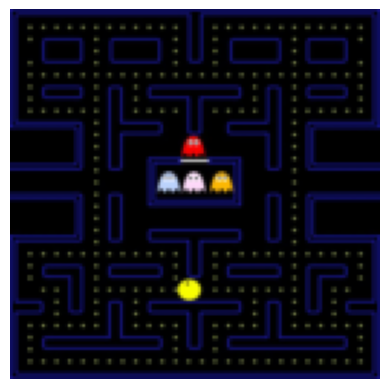

In [16]:
out_img2=data[0]["img"]
arr_ = out_img2.squeeze()
arr_ = np.transpose(arr_, (1, 2, 0))
plt.imshow(arr_)
plt.axis("off")
plt.show()


In [17]:
for param in model.parameters():
    param.requires_grad = False

for param in model.classifier.parameters():
    param.requires_grad = True
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.classifier.parameters(), lr=0.01)
model,losses = train_model(model, train_loader, val_loader,criterion, optimizer, num_epochs=10, device=DEVICE)

  0%|          | 0/175 [00:00<?, ?it/s]

242


IndexError: list index out of range

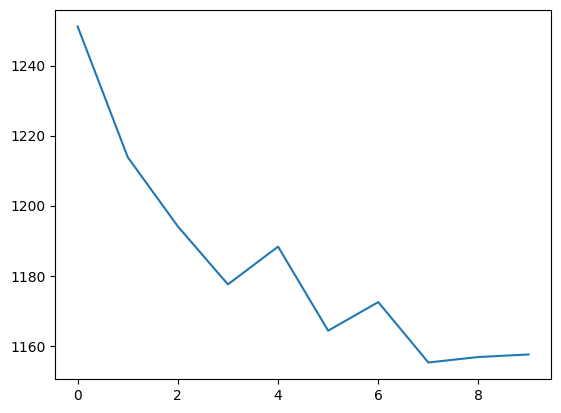

In [ ]:
plt.plot(losses)

In [ ]:
for batch in tqdm.tqdm(train_loader):
    out = model(batch["img"].to(DEVICE))
    print(out)
    break

  0%|          | 0/175 [00:00<?, ?it/s]

tensor([[ 77.3904],
        [109.4537],
        [  0.0000],
        [114.3743],
        [102.7143],
        [157.4550],
        [ 83.7933],
        [209.5729],
        [145.1928],
        [165.2421],
        [177.6188],
        [ 95.8621],
        [106.2389],
        [158.8633],
        [114.6915],
        [ 58.9128],
        [170.0179],
        [ 79.1859],
        [126.9855],
        [209.7183],
        [  0.0000],
        [ 10.6356],
        [121.5009],
        [103.0313],
        [ 71.1453],
        [116.5624],
        [248.6389],
        [  6.0183],
        [102.7549],
        [161.7333],
        [ 60.9967],
        [ 71.5013]], device='cuda:0', grad_fn=<ReluBackward0>)
